# Preamble

In [2]:
import numpy as np
import pandas as pd
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data.sampler import SubsetRandomSampler
import torchvision.transforms as transforms
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import os
from glob import glob
from sklearn.preprocessing import StandardScaler
from google.colab import drive
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
drive.mount('/content/drive')

Mounted at /content/drive


# Data Loader

In [3]:
def get_eeg_loader(data_root, batch_size=32, normalize=False):
    """
    Data loader for multi-channel EEG CSV files with variable lengths
    """

    # Prepare data paths and labels
    data_paths = []
    labels = []
    classes = ['control', 'stimulation']

    for label, class_name in enumerate(classes):
        class_path = os.path.join(data_root, class_name)
        csv_files = glob(os.path.join(class_path, '*.csv'))
        data_paths.extend(csv_files)
        labels.extend([label] * len(csv_files))

    print(f"Found {len(data_paths)} files")

    # First, check all file lengths
    file_lengths = []
    for path in data_paths:
        df = pd.read_csv(path, header=0)
        file_lengths.append(len(df))

    print(f"\nFile length statistics:")
    print(f"  Min length: {min(file_lengths)} time points")
    print(f"  Max length: {max(file_lengths)} time points")
    print(f"  Mean length: {np.mean(file_lengths):.0f} time points")
    print(f"  Std length: {np.std(file_lengths):.0f} time points")

    # Find the minimum length to trim all files to
    target_length = min(file_lengths)
    # Or use a fixed length like 24000 and trim/pad
    # target_length = 24000

    print(f"\nTrimming all files to {target_length} time points")

    # Calculate new slice size based on trimmed length
    slices_per_file = 4
    slice_size = target_length // slices_per_file
    print(f"Each slice will be {slice_size} time points")

    # Load all data to compute per-channel statistics
    if normalize:
        print("\nComputing per-channel normalization statistics...")
        all_channels_data = [[] for _ in range(4)]

        for path in data_paths:
            df = pd.read_csv(path, header=0)
            data = df.values.astype(np.float32)

            # Trim to target length
            data = data[:target_length, :]

            # Extract electrode data (columns 2-5)
            electrode_data = data[:, 1:5]

            for ch in range(4):
                all_channels_data[ch].extend(electrode_data[:, ch])

        # Compute per-channel mean and std
        channel_means = []
        channel_stds = []
        for ch in range(4):
            ch_data = np.array(all_channels_data[ch])
            channel_means.append(np.mean(ch_data))
            channel_stds.append(np.std(ch_data))
            print(f"Channel {ch+1}: Mean = {channel_means[-1]:.4f}, Std = {channel_stds[-1]:.4f}")

    # Now load, trim, slice, and normalize
    all_slices = []
    all_slice_labels = []

    for path, label in zip(data_paths, labels):
        df = pd.read_csv(path, header=0)
        data = df.values.astype(np.float32)

        # Trim to target length
        data = data[:target_length, :]

        # Extract electrode data (columns 2-5)
        electrode_data = data[:, 1:5]

        # Slice into equal parts
        for i in range(slices_per_file):
            start = i * slice_size
            end = start + slice_size
            slice_data = electrode_data[start:end, :]

            # Normalize if requested
            if normalize:
                normalized_slice = np.zeros_like(slice_data)
                for ch in range(4):
                    normalized_slice[:, ch] = (slice_data[:, ch] - channel_means[ch]) / (channel_stds[ch] + 1e-8)
                slice_data = normalized_slice

            # Transpose to (channels, time)
            slice_data = slice_data.T

            all_slices.append(slice_data)
            all_slice_labels.append(label)

    # Convert to numpy array
    X = np.array(all_slices)
    y = np.array(all_slice_labels)

    print(f"\nFinal data shape: {X.shape}")
    print(f"  - Total slices: {X.shape[0]}")
    print(f"  - Channels: {X.shape[1]}")
    print(f"  - Time points per slice: {X.shape[2]}")

    # Convert to tensors
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)

    dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)

    # Split
    total = len(dataset)
    train_size = int(0.8 * total)
    val_size = int(0.1 * total)
    test_size = total - train_size - val_size

    print(f"\nSplits - Train: {train_size}, Val: {val_size}, Test: {test_size}")

    generator = torch.Generator().manual_seed(42)
    train_dataset, val_dataset, test_dataset = random_split(
        dataset, [train_size, val_size, test_size],
        generator=generator
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    norm_params = {'channel_means': channel_means, 'channel_stds': channel_stds} if normalize else None

    return train_loader, val_loader, test_loader, classes, norm_params

data_root = '/content/drive/MyDrive/aps360/project/Filtered_Data'
train_loader, val_loader, test_loader, classes, norm_params = get_eeg_loader(data_root, batch_size=32, normalize=True)

Found 236 files

File length statistics:
  Min length: 24000 time points
  Max length: 40114 time points
  Mean length: 24086 time points
  Std length: 1079 time points

Trimming all files to 24000 time points
Each slice will be 6000 time points

Computing per-channel normalization statistics...
Channel 1: Mean = 0.0019, Std = 6.3779
Channel 2: Mean = 0.0036, Std = 5.5292
Channel 3: Mean = 0.0032, Std = 7.3728
Channel 4: Mean = 0.0001, Std = 5.4784

Final data shape: (944, 4, 6000)
  - Total slices: 944
  - Channels: 4
  - Time points per slice: 6000

Splits - Train: 755, Val: 94, Test: 95


# Useful Functions for Training and Testing

In [4]:
def train_net(model, train_loader, val_loader=None, learning_rate=0.001, num_epochs=5, plot=True):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    print(f"Using device: {device}")
    print(f"Model: {model.name if hasattr(model, 'name') else 'Unnamed'}")

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-3)

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    # ADDED: Best model tracking
    best_val_acc = 0
    best_model_state = None

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        batch_count = 0
        # CHANGED: 'images' → 'data' to be more generic
        for data, labels in train_loader:
            batch_count += 1
            data, labels = data.to(device), labels.to(device)

            # Forward pass
            outputs = model(data)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        print(f"  Train Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_acc:.2f}%")

        # Validation phase
        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0

            with torch.no_grad():
                for data, labels in val_loader:
                    data, labels = data.to(device), labels.to(device)
                    outputs = model(data)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item()

                    _, predicted = torch.max(outputs.data, 1)
                    val_total += labels.size(0)
                    val_correct += (predicted == labels).sum().item()

            val_epoch_loss = val_loss / len(val_loader)
            val_epoch_acc = 100 * val_correct / val_total

            val_losses.append(val_epoch_loss)
            val_accuracies.append(val_epoch_acc)

            # ADDED: Save best model
            if val_epoch_acc > best_val_acc:
                best_val_acc = val_epoch_acc
                best_model_state = model.state_dict().copy()
                print(f"  → New best model! Val Acc: {best_val_acc:.2f}%")

            print(f"  Val Loss: {val_epoch_loss:.4f}, Val Accuracy: {val_epoch_acc:.2f}%")
            print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")


    # ADDED: Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\nLoaded best model with validation accuracy: {best_val_acc:.2f}%")

    # Plot training and validation curves
    if plot:
        plt.figure(figsize=(14, 5))

        # Plot loss
        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label='Training Loss', marker='o', linewidth=2)
        if val_loader is not None and val_losses:
            plt.plot(val_losses, label='Validation Loss', marker='s', linewidth=2)
        plt.title('Loss vs. Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Plot accuracy
        plt.subplot(1, 2, 2)
        plt.plot(train_accuracies, label='Training Accuracy', marker='o', linewidth=2)
        if val_loader is not None and val_accuracies:
            plt.plot(val_accuracies, label='Validation Accuracy', marker='s', linewidth=2)
        plt.title('Accuracy vs. Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy (%)')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # ADDED: Print final statistics
        print("\n" + "="*50)
        print("TRAINING COMPLETE")
        print("="*50)
        print(f"Final Training Accuracy: {train_accuracies[-1]:.2f}%")
        if val_accuracies:
            print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
            print(f"Final Validation Accuracy: {val_accuracies[-1]:.2f}%")
        print("="*50)

    return train_losses, train_accuracies, val_losses, val_accuracies

In [5]:
def evaluate_model(model, test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss()

    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    avg_loss = total_loss / len(test_loader)

    print(f"Test Accuracy: {accuracy:.2f}%, Test Loss: {avg_loss:.4f}")
    return accuracy, avg_loss

In [6]:
def plot_confusion_matrix(model, test_loader, classes):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data, labels in test_loader:
            data, labels = data.to(device), labels.to(device)
            outputs = model(data)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=classes, yticklabels=classes,
                cmap='Blues')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title(f'Confusion matrix — {model.name if hasattr(model, "name") else "model"}')
    plt.tight_layout()
    plt.show()

    # Per-class breakdown
    print(classification_report(all_labels, all_preds, target_names=classes))

In [15]:
from sklearn.metrics import roc_auc_score, roc_curve
def plot_auroc(model, test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for data, labels in test_loader:
            data, labels = data.to(device), labels.to(device)
            outputs = model(data)
            # Convert logits to probabilities
            probs = torch.softmax(outputs, dim=1)
            # Take probability of positive class (stimulation = class 1)
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute AUROC
    auroc = roc_auc_score(all_labels, all_probs)

    # Compute ROC curve points
    fpr, tpr, _ = roc_curve(all_labels, all_probs)

    # Plot
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, linewidth=2,
             label=f'{model.name if hasattr(model, "name") else "model"} (AUROC = {auroc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random chance')
    plt.xlabel('False positive rate')
    plt.ylabel('True positive rate')
    plt.title('ROC curve')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"AUROC: {auroc:.4f}")
    return auroc

# Basic GRU

In [8]:
class GRU(nn.Module):
    def __init__(self, input_size=4, hidden_size=64, num_layers=2,
                 num_classes=2, dropout=0.3):
        super(GRU, self).__init__()
        self.name = "GRU_Hierarchical"

        self.gru1 = nn.GRU(input_size, hidden_size, batch_first=True)
        self.pool1 = nn.AvgPool1d(4)     # 6000 → 1500

        self.gru2 = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.pool2 = nn.AvgPool1d(4)     # 1500 → 375

        self.gru3 = nn.GRU(hidden_size, hidden_size,
                           batch_first=True, bidirectional=True)
        # 375 steps — manageable for bidirectional GRU

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)              # (batch, 6000, 4)

        x, _ = self.gru1(x)                 # (batch, 6000, 128)
        x = self.dropout(x)
        x = x.permute(0, 2, 1)
        x = self.pool1(x)                   # (batch, 128, 1500)
        x = x.permute(0, 2, 1)              # (batch, 1500, 128)

        x, _ = self.gru2(x)                 # (batch, 1500, 128)
        x = self.dropout(x)
        x = x.permute(0, 2, 1)
        x = self.pool2(x)                   # (batch, 128, 375)
        x = x.permute(0, 2, 1)              # (batch, 375, 128)

        _, hidden = self.gru3(x)
        x = torch.cat([hidden[-2], hidden[-1]], dim=1)  # (batch, 256)

        return self.classifier(x)

Using device: cuda
Model: GRU_Hierarchical

Epoch 1/100
  Train Loss: 0.6934, Train Accuracy: 49.67%
  → New best model! Val Acc: 45.74%
  Val Loss: 0.6957, Val Accuracy: 45.74%
  LR: 0.000300

Epoch 2/100
  Train Loss: 0.6922, Train Accuracy: 52.32%
  Val Loss: 0.7002, Val Accuracy: 44.68%
  LR: 0.000300

Epoch 3/100
  Train Loss: 0.6910, Train Accuracy: 52.32%
  Val Loss: 0.7006, Val Accuracy: 43.62%
  LR: 0.000300

Epoch 4/100
  Train Loss: 0.6911, Train Accuracy: 52.58%
  Val Loss: 0.7005, Val Accuracy: 43.62%
  LR: 0.000300

Epoch 5/100
  Train Loss: 0.6910, Train Accuracy: 52.45%
  Val Loss: 0.7011, Val Accuracy: 43.62%
  LR: 0.000300

Epoch 6/100
  Train Loss: 0.6928, Train Accuracy: 52.98%
  Val Loss: 0.6968, Val Accuracy: 45.74%
  LR: 0.000300

Epoch 7/100
  Train Loss: 0.6933, Train Accuracy: 52.32%
  Val Loss: 0.7005, Val Accuracy: 43.62%
  LR: 0.000300

Epoch 8/100
  Train Loss: 0.6904, Train Accuracy: 52.58%
  Val Loss: 0.6980, Val Accuracy: 45.74%
  LR: 0.000300

Epoch 9/

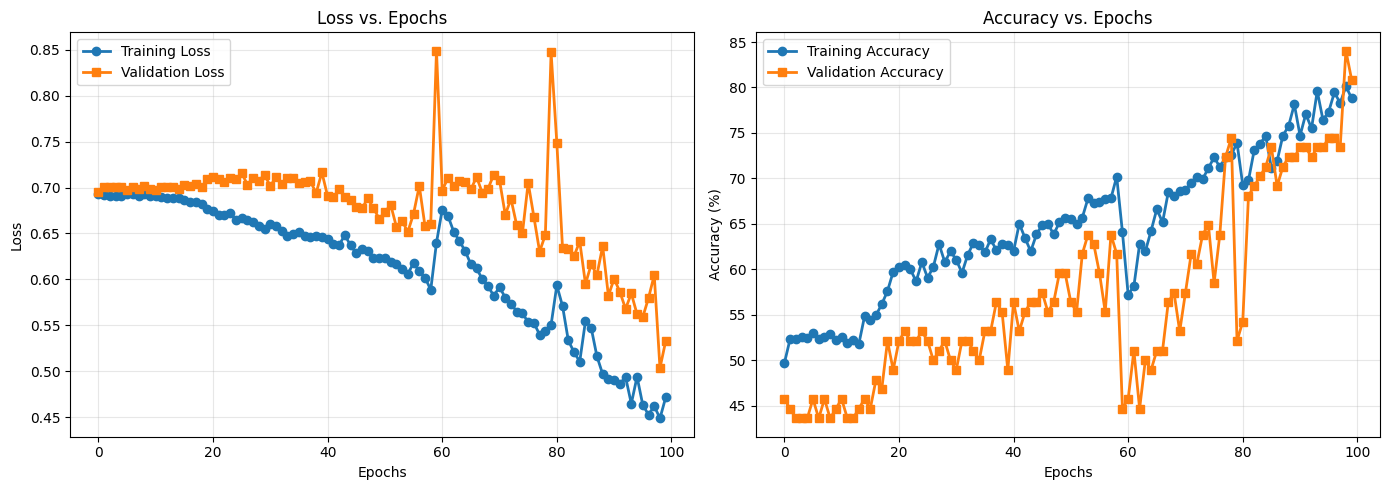


TRAINING COMPLETE
Final Training Accuracy: 78.81%
Best Validation Accuracy: 84.04%
Final Validation Accuracy: 80.85%


In [35]:
model_GRU = GRU()
train_losses, train_accuracies, val_losses, val_accuracies = train_net(model_GRU, train_loader, val_loader, learning_rate=0.0003, num_epochs=100, plot=True)

In [36]:
test_acc, test_loss = evaluate_model(model_GRU, test_loader)

Test Accuracy: 71.58%, Test Loss: 0.6088


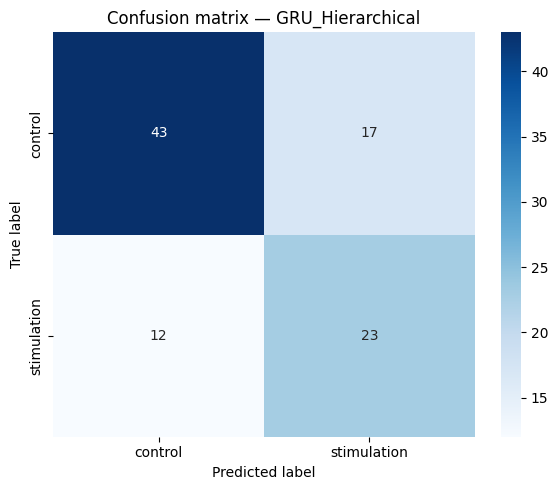

              precision    recall  f1-score   support

     control       0.78      0.72      0.75        60
 stimulation       0.57      0.66      0.61        35

    accuracy                           0.69        95
   macro avg       0.68      0.69      0.68        95
weighted avg       0.71      0.69      0.70        95



In [13]:
plot_confusion_matrix(model_GRU, test_loader, classes)

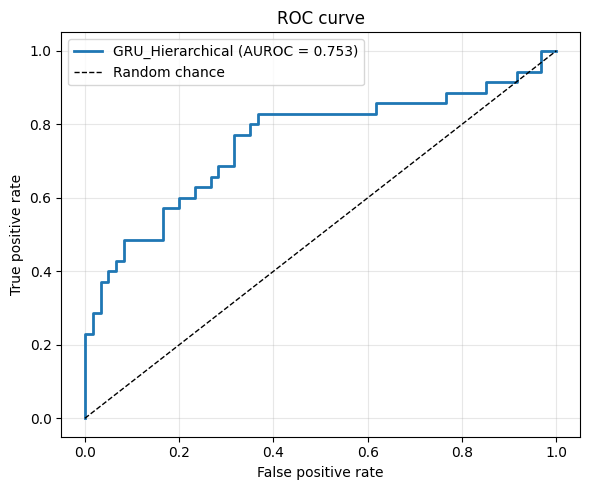

AUROC: 0.7529


np.float64(0.7528571428571429)

In [37]:
plot_auroc(model_GRU, test_loader)

# GRU combined with CNN (sequential)

In [17]:
class GRU_improved2(nn.Module):
    def __init__(self, input_size=4, hidden_size=32, num_layers=2,
                 num_classes=2, dropout=0.6):
        super(GRU_improved2, self).__init__()
        self.name = "GRU_improved2"

        # Learned compression instead of blind averaging
        # Small, no large feature expansion — GRU is still doing the real work
        self.compressor = nn.Sequential(
            nn.Conv1d(4, 4, kernel_size=16, stride=8, padding=4),  # 6000 → 750
            nn.ReLU(),
            nn.Conv1d(4, 4, kernel_size=8, stride=4, padding=2),   # 750 → 188
            nn.ReLU(),
        )
        # Output is still 4 channels — GRU sees same input_size as before

        self.gru = nn.GRU(
            input_size=4,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x: (batch, 4, 6000)
        x = self.compressor(x)          # (batch, 4, ~188)
        x = x.permute(0, 2, 1)         # (batch, ~188, 4)
        _, hidden = self.gru(x)
        x = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.classifier(x)

Using device: cuda
Model: GRU_improved2

Epoch 1/100
  Train Loss: 0.6947, Train Accuracy: 49.80%
  → New best model! Val Acc: 57.45%
  Val Loss: 0.6915, Val Accuracy: 57.45%
  LR: 0.000500

Epoch 2/100
  Train Loss: 0.6938, Train Accuracy: 49.67%
  Val Loss: 0.6969, Val Accuracy: 43.62%
  LR: 0.000500

Epoch 3/100
  Train Loss: 0.6935, Train Accuracy: 49.80%
  Val Loss: 0.6966, Val Accuracy: 43.62%
  LR: 0.000500

Epoch 4/100
  Train Loss: 0.6944, Train Accuracy: 47.55%
  Val Loss: 0.6953, Val Accuracy: 43.62%
  LR: 0.000500

Epoch 5/100
  Train Loss: 0.6945, Train Accuracy: 50.20%
  Val Loss: 0.6944, Val Accuracy: 43.62%
  LR: 0.000500

Epoch 6/100
  Train Loss: 0.6896, Train Accuracy: 54.30%
  Val Loss: 0.6947, Val Accuracy: 43.62%
  LR: 0.000500

Epoch 7/100
  Train Loss: 0.6926, Train Accuracy: 50.86%
  Val Loss: 0.6963, Val Accuracy: 43.62%
  LR: 0.000500

Epoch 8/100
  Train Loss: 0.6916, Train Accuracy: 52.72%
  Val Loss: 0.6965, Val Accuracy: 43.62%
  LR: 0.000500

Epoch 9/100

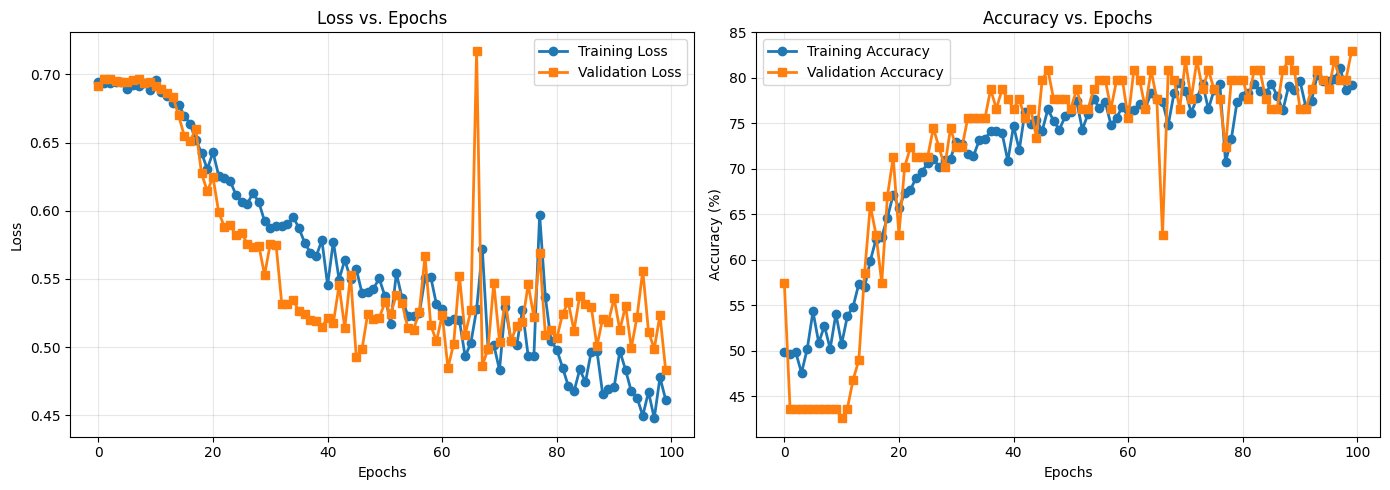


TRAINING COMPLETE
Final Training Accuracy: 79.21%
Best Validation Accuracy: 82.98%
Final Validation Accuracy: 82.98%


In [43]:
model_GRU2 = GRU_improved2()
train_losses, train_accuracies, val_losses, val_accuracies = train_net(model_GRU2, train_loader, val_loader, learning_rate=0.0005, num_epochs=100, plot=True)

In [44]:
test_acc, test_loss = evaluate_model(model_GRU2, test_loader)

Test Accuracy: 76.84%, Test Loss: 0.5318


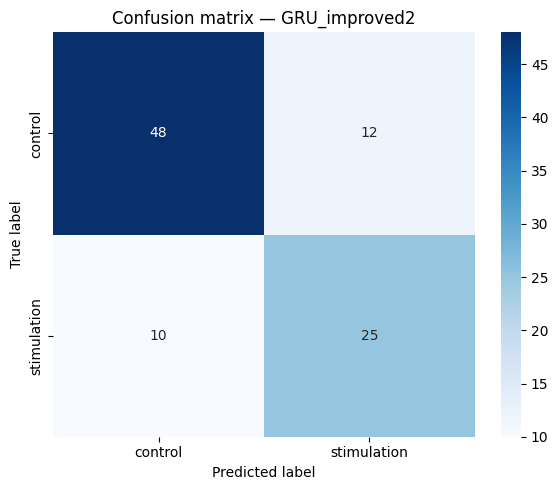

              precision    recall  f1-score   support

     control       0.83      0.80      0.81        60
 stimulation       0.68      0.71      0.69        35

    accuracy                           0.77        95
   macro avg       0.75      0.76      0.75        95
weighted avg       0.77      0.77      0.77        95



In [ ]:
plot_confusion_matrix(model_GRU2, test_loader, classes)

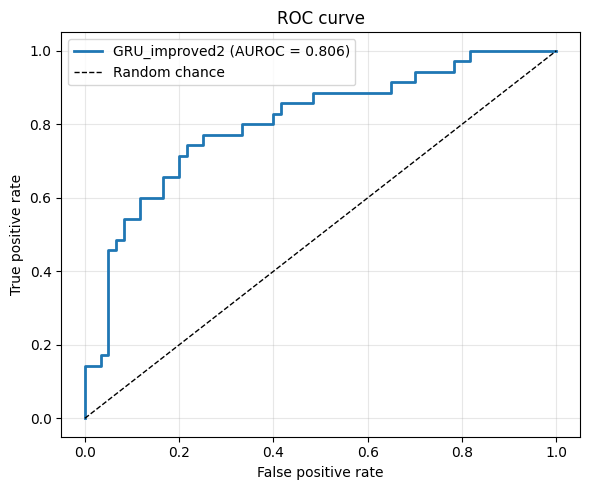

AUROC: 0.8062


np.float64(0.8061904761904762)

In [45]:
plot_auroc(model_GRU2, test_loader)

# GRU CNN Parallel Fusion

In [25]:
class GCFNClassifier(nn.Module):
    def __init__(self, input_channels=4, hidden_size=32,
                 num_classes=2, dropout=0.5):
        super(GCFNClassifier, self).__init__()
        self.name = "GCFN_Parallel"

        self.cnn_branch = nn.Sequential(
            nn.Conv1d(4, 16, kernel_size=64, stride=8, padding=32),
            nn.ReLU(),
            nn.MaxPool1d(5),
            nn.Conv1d(16, 32, kernel_size=16, stride=5, padding=8),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),  # collapses time dimension to exactly 1
            nn.Flatten(),             # → always exactly 32, regardless of input size
            nn.Dropout(dropout)
        )

        self.gru1 = nn.GRU(input_channels, hidden_size, batch_first=True)
        self.pool = nn.AvgPool1d(16)   # 6000 → 375
        self.gru2 = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Sequential(
            nn.Linear(32 + 32, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        cnn_out = self.cnn_branch(x)               # (batch, 32)

        x_gru = x.permute(0, 2, 1)                # (batch, 6000, 4)
        x_gru, _ = self.gru1(x_gru)               # (batch, 6000, 32)
        x_gru = self.dropout(x_gru)
        x_gru = x_gru.permute(0, 2, 1)
        x_gru = self.pool(x_gru)                   # (batch, 32, 375)
        x_gru = x_gru.permute(0, 2, 1)            # (batch, 375, 32)
        _, hidden = self.gru2(x_gru)
        gru_out = hidden.squeeze(0)                # (batch, 32)

        fused = torch.cat([cnn_out, gru_out], dim=1)
        return self.classifier(fused)

Using device: cuda
Model: GCFN_Parallel

Epoch 1/50
  Train Loss: 0.6907, Train Accuracy: 52.32%
  → New best model! Val Acc: 43.62%
  Val Loss: 0.7052, Val Accuracy: 43.62%
  LR: 0.001000

Epoch 2/50
  Train Loss: 0.6814, Train Accuracy: 52.98%
  Val Loss: 0.6896, Val Accuracy: 43.62%
  LR: 0.001000

Epoch 3/50
  Train Loss: 0.6684, Train Accuracy: 55.89%
  → New best model! Val Acc: 67.02%
  Val Loss: 0.6635, Val Accuracy: 67.02%
  LR: 0.001000

Epoch 4/50
  Train Loss: 0.6444, Train Accuracy: 64.24%
  Val Loss: 0.6690, Val Accuracy: 59.57%
  LR: 0.001000

Epoch 5/50
  Train Loss: 0.6375, Train Accuracy: 65.30%
  → New best model! Val Acc: 70.21%
  Val Loss: 0.6229, Val Accuracy: 70.21%
  LR: 0.001000

Epoch 6/50
  Train Loss: 0.6144, Train Accuracy: 65.03%
  Val Loss: 0.6041, Val Accuracy: 65.96%
  LR: 0.001000

Epoch 7/50
  Train Loss: 0.5938, Train Accuracy: 69.40%
  → New best model! Val Acc: 72.34%
  Val Loss: 0.6121, Val Accuracy: 72.34%
  LR: 0.001000

Epoch 8/50
  Train Loss:

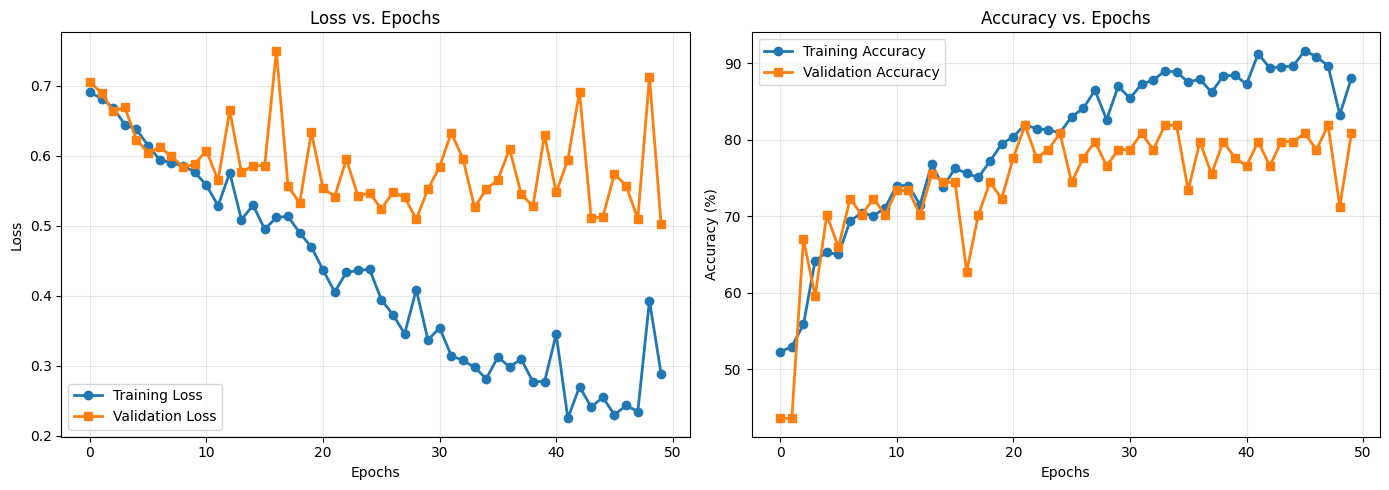


TRAINING COMPLETE
Final Training Accuracy: 88.08%
Best Validation Accuracy: 81.91%
Final Validation Accuracy: 80.85%


In [46]:
model_GCFN2 = GCFNClassifier()
train_losses, train_accuracies, val_losses, val_accuracies = train_net(
    model_GCFN2, train_loader, val_loader,
    learning_rate=0.001,
    num_epochs=50,
    plot=True
)

In [47]:
test_acc, test_loss = evaluate_model(model_GCFN2, test_loader)

Test Accuracy: 81.05%, Test Loss: 0.4735


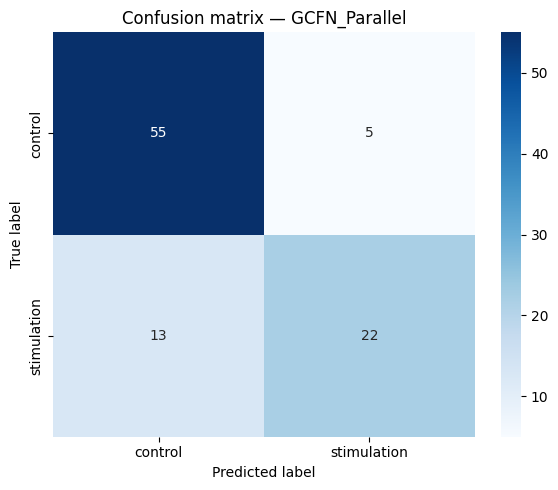

              precision    recall  f1-score   support

     control       0.81      0.92      0.86        60
 stimulation       0.81      0.63      0.71        35

    accuracy                           0.81        95
   macro avg       0.81      0.77      0.78        95
weighted avg       0.81      0.81      0.80        95



In [ ]:
plot_confusion_matrix(model_GCFN2, test_loader, classes)

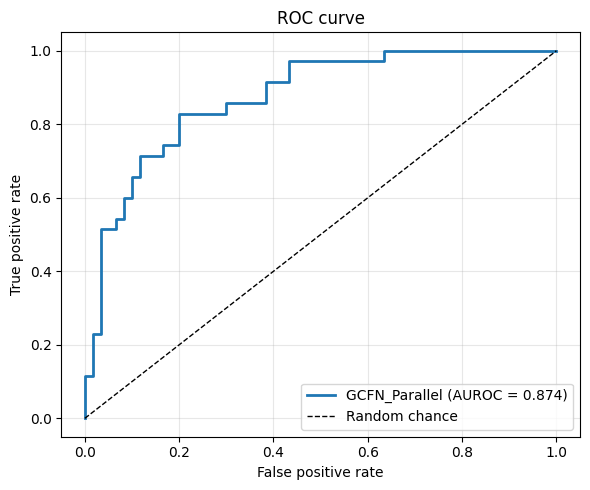

AUROC: 0.8743


np.float64(0.8742857142857142)

In [48]:
plot_auroc(model_GCFN2, test_loader)